# 🩺 Medical Insurance Charges — Exploratory Data Analysis

**Objective:**  
To analyze the insurance dataset and uncover which factors most strongly influence medical charges.  
We will examine demographic (age, sex, children), lifestyle (smoking, BMI), and regional factors to identify key drivers of cost.


SETUP

In [68]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

LOAD DATA

In [69]:
df=pd.read_csv(r"C:\Users\LENOVO\Desktop\da\python\insurance\insurance.csv")

DATA WRANGLING & CLEANING

In [107]:
df1=df.copy()

In [108]:
df1.shape

(1337, 7)

In [119]:
df1.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,16884.92
1,18,male,33.77,1,no,southeast,1725.55
2,28,male,33.00,3,no,southeast,4449.46
3,33,male,22.70,0,no,northwest,21984.47
4,32,male,28.88,0,no,northwest,3866.86


In [120]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   object 
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   object 
 5   region    1337 non-null   object 
 6   charges   1337 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 83.6+ KB


In [121]:
check_null=df1.isnull().sum()
check_null

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [122]:
df1[df1.duplicated()]

,age,sex,bmi,children,smoker,region,charges


In [123]:
df1=df1.drop_duplicates()

In [124]:
df1[df1.duplicated()]

,age,sex,bmi,children,smoker,region,charges


In [135]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)


In [136]:
Numerical_column=df1.select_dtypes(include="number").columns.to_list()
Categorical_column=df1.select_dtypes(exclude="number").columns.to_list()
print('Numerical column: ',Numerical_column)
print('Categorical column: ',Categorical_column)


Numerical column:  ['age', 'bmi', 'children', 'charges']
Categorical column:  ['sex', 'smoker', 'region']


In [137]:
df1.describe()

,age,bmi,children,charges
count,1337.00,1337.00,1337.00,1337.00
mean,39.22,30.66,1.10,13279.12
std,14.04,6.10,1.21,12110.36
min,18.00,15.96,0.00,1121.87
25%,27.00,26.29,0.00,4746.34
50%,39.00,30.40,1.00,9386.16
75%,51.00,34.70,2.00,16657.72
max,64.00,53.13,5.00,63770.43


In [138]:
df1.sex.value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [128]:
df1.smoker.value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

In [129]:
df1.region.value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

EXPLORATORY DATA ANALYSIS

UNIVARIATE DISTRIBUTION

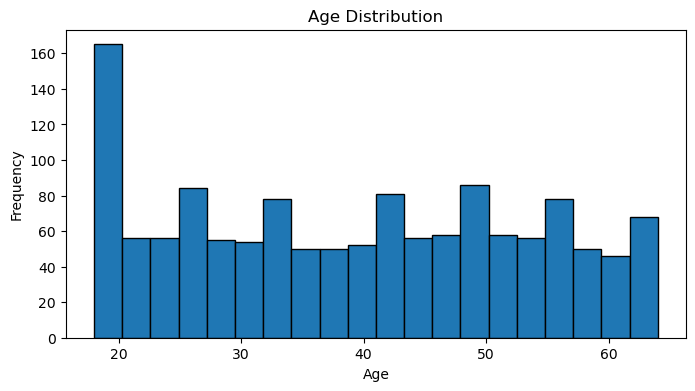

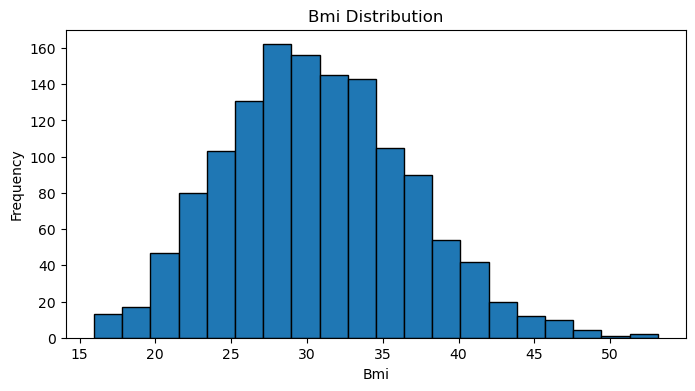

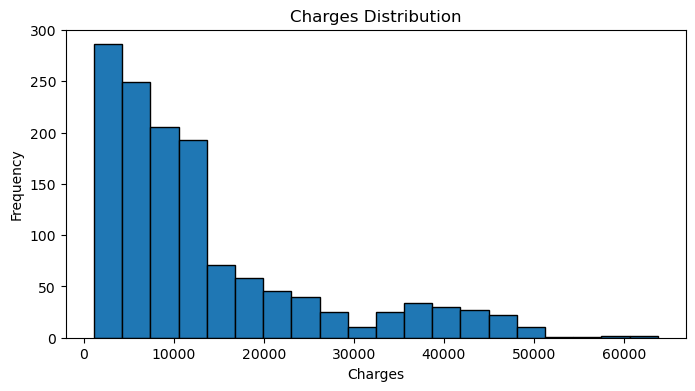

In [130]:
for col in ['age', 'bmi', 'charges']:
    df[col].plot(kind='hist', bins=20, figsize=(8,4), edgecolor='black')
    plt.title(f"{col.capitalize()} Distribution")
    plt.xlabel(col.capitalize())
    plt.show()



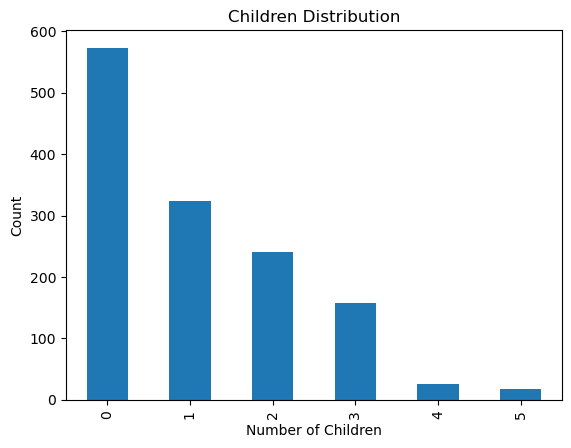

In [131]:
df['children'].value_counts().plot(kind='bar')
plt.title("Children Distribution")
plt.xlabel("Number of Children")
plt.ylabel("Count")
plt.show()


Age Insight:
This suggests that while the dataset is fairly representative across adult age ranges, it is dominated by younger individuals, which could influence any analysis or model outcomes (e.g., health costs may appear lower due to fewer elderly cases).

BMI Insight:
This suggests that while BMI spans a broad range, the dataset is dominated by overweight to obese individuals (25–35), which could skew analysis of medical charges toward conditions linked to higher BMI.

Charges Insight:
This suggests that most individuals incur relatively low charges, but a small number face very high costs, creating a right-skewed distribution that may affect predictive modeling.

No. of children: 
The majority of policyholders have no children (0) — this is the largest group, close to 600 records.
The number of policyholders decreases steadily as the number of children increases.
A smaller portion have 1 or 2 children, while only a few have 4 or 5 children.


Bivariate Analysis — Charges vs Categories

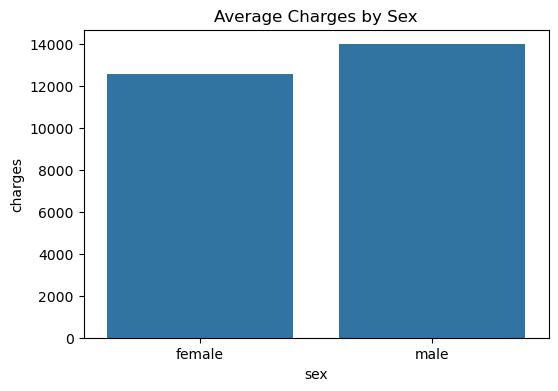

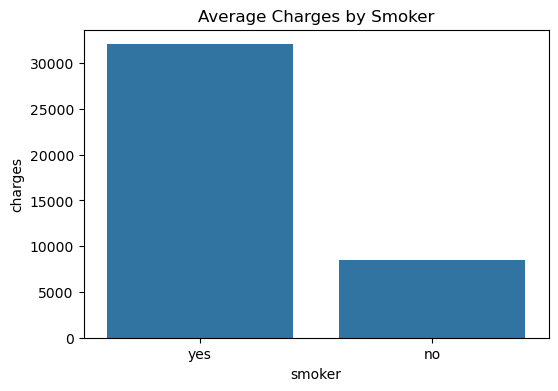

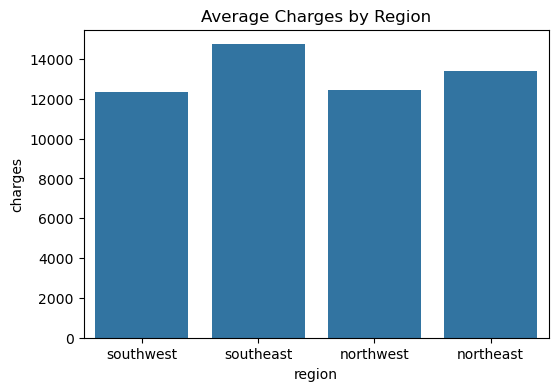

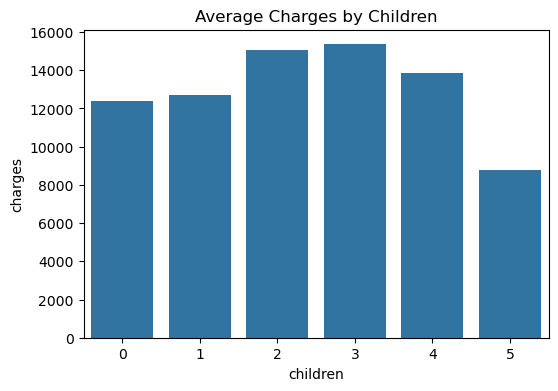

In [132]:
for col in ['sex','smoker','region','children']:
    plt.figure(figsize=(6,4))
    sns.barplot(x=col, y='charges', data=df, estimator=np.mean, errorbar=None)
    plt.title(f"Average Charges by {col.capitalize()}")
    plt.show()


Smoker vs Charges:
This suggests that smokers face dramatically higher charges compared to non-smokers, making smoking status the single most influential factor in medical costs.

Sex vs Charges:
This suggests that average charges are nearly identical for males and females, indicating gender is not a major factor in insurance costs.

Region vs Charges:
This suggests that average charges are broadly similar across regions, with only minor differences that are unlikely to be statistically significant.

Children vs Charges:
This suggests that the number of children has minimal effect on charges, possibly because the direct medical costs of children are less significant than adult health risks.

Correlation Heatmap

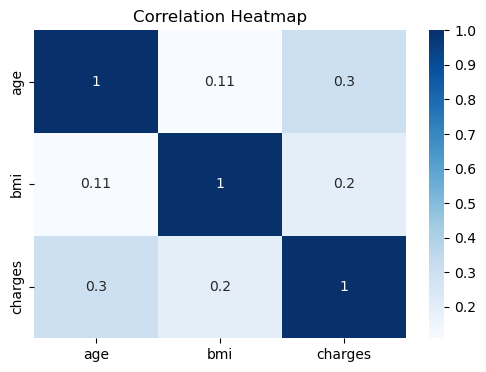

In [133]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['age','bmi','charges']].corr(), annot=True, cmap='Blues')
plt.title("Correlation Heatmap")
plt.show()


This suggests that age and BMI both show positive correlation with charges, but smoking (not numeric) is the dominant categorical driver.

Scatter Plots

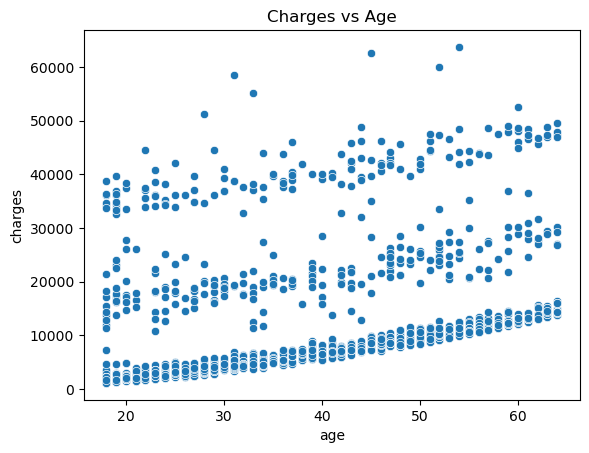

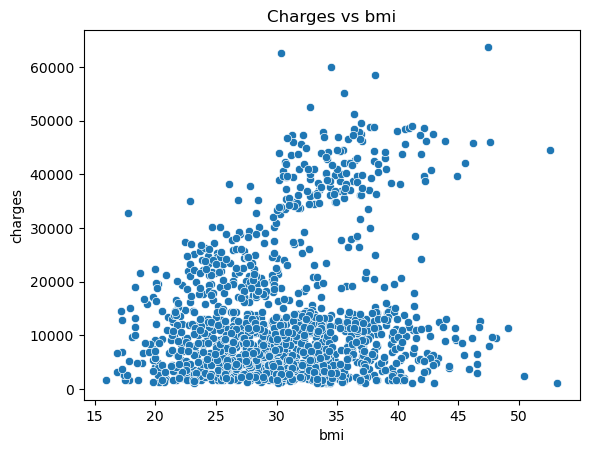

In [140]:
sns.scatterplot(x='age', y='charges', data=df1)
plt.title("Charges vs Age")
plt.show()

sns.scatterplot(x='bmi', y='charges', data=df1)
plt.title("Charges vs bmi")
plt.show()


Age vs Charges:
This suggests that charges increase with age, especially after 40, highlighting the impact of age-related health risks on insurance costs.

BMI vs Charges:
This suggests that higher BMI is associated with higher charges, particularly among smokers, reinforcing the health risk connection between obesity and medical costs.

## Key Findings
- Smoking is the strongest predictor of higher charges.
- Age shows a clear positive relationship with charges.
- Higher BMI contributes to elevated charges, especially in smokers.
- Gender, number of children, and region have minimal impact.
- Charges are right-skewed with heavy outliers, requiring log transformation for modeling.
